In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [6]:
df = pd.read_csv('./data/diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [7]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder


encoder = OrdinalEncoder(categories= [df['gender'].unique()] )
df['gender'] = encoder.fit_transform(df[['gender']])
encoder = OrdinalEncoder(categories= [df['smoking_history'].unique()] )
df['smoking_history'] = encoder.fit_transform(df[['smoking_history']])




In [8]:
df.iloc[:, :-1]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,0.0,80.0,0,1,0.0,25.19,6.6,140
1,0.0,54.0,0,0,1.0,27.32,6.6,80
2,1.0,28.0,0,0,0.0,27.32,5.7,158
3,0.0,36.0,0,0,2.0,23.45,5.0,155
4,1.0,76.0,1,1,2.0,20.14,4.8,155
...,...,...,...,...,...,...,...,...
99995,0.0,80.0,0,0,1.0,27.32,6.2,90
99996,0.0,2.0,0,0,1.0,17.37,6.5,100
99997,1.0,66.0,0,0,3.0,27.83,5.7,155
99998,0.0,24.0,0,0,0.0,35.42,4.0,100


In [9]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], test_size=0.2, random_state=42)

# DecisionTree

In [10]:
from sklearn import tree

dt = tree.DecisionTreeClassifier(max_depth=10, min_samples_split= 5)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


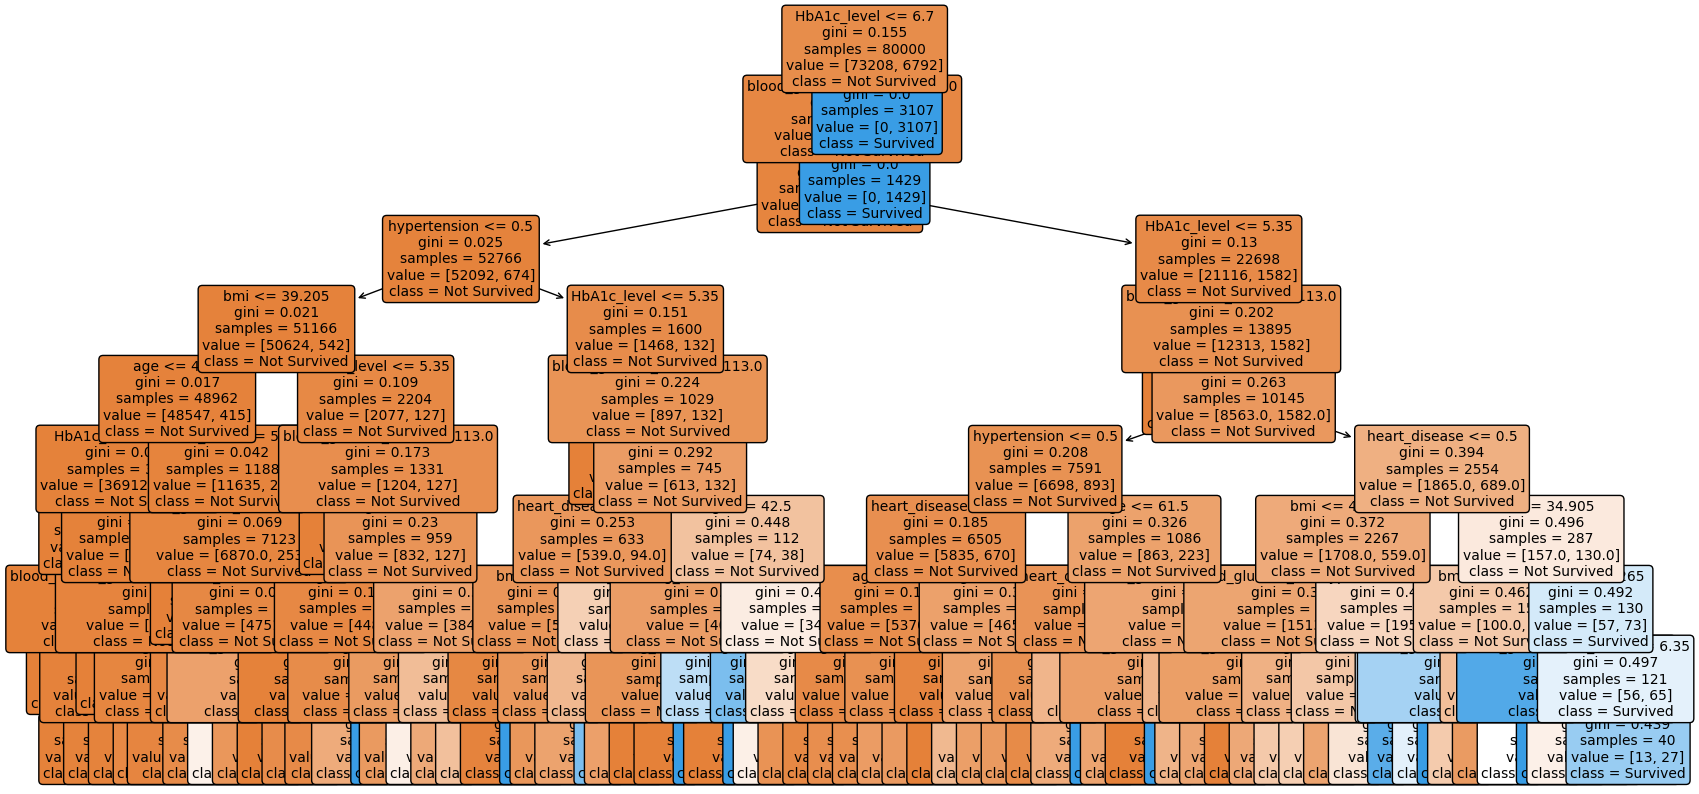

In [11]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))  # chỉnh kích thước hình
tree.plot_tree(dt, 
               filled=True,        # tô màu theo lớp
               feature_names=X_train.columns,  # tên đặc trưng
               class_names=['Not Survived', 'Survived'],  # tên nhãn
               rounded=True, 
               fontsize=10)
plt.show()


## tìm tham số tối ưu

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}
dt = DecisionTreeClassifier(random_state=42)


grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,                  # 5-fold cross-validation
    scoring='accuracy',    # hoặc 'f1', 'recall', v.v.
    n_jobs=-1,             # chạy song song
    verbose=2    ,          # in log ra để theo dõi tiến trình
    return_train_score=True
)
grid_search.fit(X_train, y_train)



Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


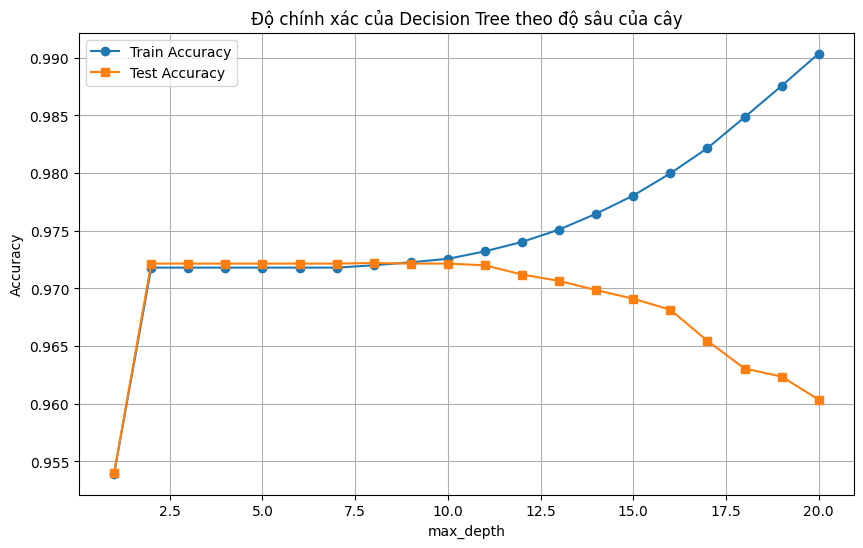

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Giả sử bạn đã có:
# X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2, random_state=42)

max_depths = range(1, 21)
train_scores = []
test_scores = []

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    
    # Độ chính xác train và test
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Vẽ biểu đồ
plt.figure(figsize=(10,6))
plt.plot(max_depths, train_scores, marker='o', label='Train Accuracy')
plt.plot(max_depths, test_scores, marker='s', label='Test Accuracy')

plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Độ chính xác của Decision Tree theo độ sâu của cây')
plt.legend()
plt.grid(True)
plt.show()


# RandomForest

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier\
(n_estimators=10, criterion='gini', max_depth=3,
min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0,
bootstrap=True, oob_score=False, n_jobs=None,
random_state=4, verbose=0, warm_start=False, class_weight=None)

In [15]:
rf_params_ex = {'n_estimators':list(range(10,110,10))}
cv_rf_ex = GridSearchCV(rf, param_grid=rf_params_ex,
scoring='roc_auc', n_jobs=None,
refit=True, cv=4, verbose=1,
error_score=np.nan,
return_train_score=True)

cv_rf_ex.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


,estimator,RandomForestC...andom_state=4)
,param_grid,"{'n_estimators': [10, 20, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,30


<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
C:\Users\LENOVO-PC\AppData\Local\Temp\ipykernel_19552\1889697650.py:12: SyntaxWarning: invalid escape sequence '\p'
  axs[1].set_ylabel('Mean testing ROC AUC $\pm$ 1 SE ')


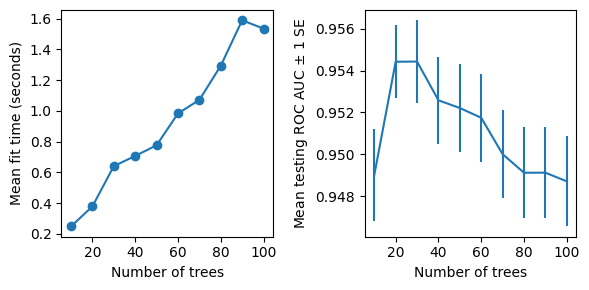

In [16]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_fit_time'],
'-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_test_score'],
yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC $\pm$ 1 SE ')
plt.tight_layout()

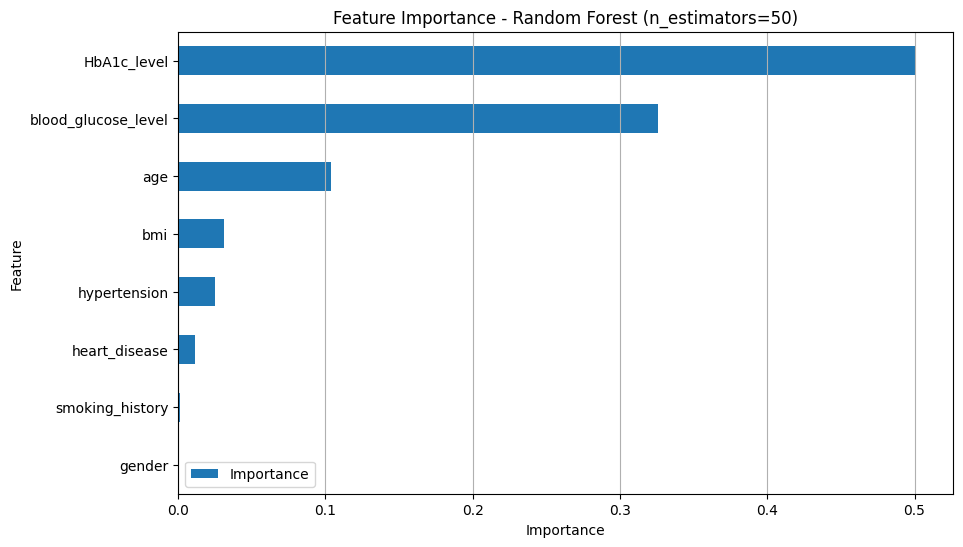

In [17]:

features_response = X_train.columns


feat_imp_df = pd.DataFrame({
    'Importance': cv_rf_ex.best_estimator_.feature_importances_
}, index=features_response)


feat_imp_df.sort_values('Importance', ascending=True).plot.barh(figsize=(10,6))
plt.title('Feature Importance - Random Forest (n_estimators=50)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x')
plt.show()
